#### Selected Problem Set

### Infer a continuous random variable (r.v.) from a discrete measurement

The problem setting

**Infer a continuous random variable (r.v.) from a discrete measurement**
-   **Q (continuous r.v.)**
$ f_Q(q) = \begin{cases} 6q(1-q) & \text{for } 0 \le q \le 1 \\ 0 & \text{otherwise} \end{cases} $

-   **Y (discrete Bernoulli r.v.)**
$ P(Y=1|Q=q) = q \\ P(Y=0|Q=q) = 1-q $

Which can be written as:
$ P_{Y|Q}(y|q) = \begin{cases} q & \text{for } y=1 \\ 1-q & \text{for } y=0 \\ 0 & \text{otherwise} \end{cases} $

**Derivations for the conditional PDFs $f_{Q|Y}(q|y)$:**

According to Bayes' theorem, the posterior PDF is given by:
$ f_{Q|Y}(q|y) = \frac{f_Q(q) \cdot P_{Y|Q}(y|q)}{\int_0^1 f_Q(q) \cdot P_{Y|Q}(y|q) \mathrm{d}q} $

1.  **For $Y=1$ (success):**
$ f_{Q|Y}(q|1) = \frac{f_Q(q) \cdot P_{Y|Q}(1|q)}{\int_0^1 f_Q(q) \cdot P_{Y|Q}(1|q) \mathrm{d}q}

Substitute $f_Q(q) = 6q(1-q)$ and $P_{Y|Q}(1|q) = q$:
$ f_{Q|Y}(q|1) = \frac{6q(1-q) \cdot q}{\int_0^1 6q(1-q) \cdot q \mathrm{d}q} = \frac{6q^2(1-q)}{\int_0^1 (6q^2 - 6q^3) \mathrm{d}q} $

Calculate the integral:
$ \int_0^1 (6q^2 - 6q^3) \mathrm{d}q = \left[ 2q^3 - \frac{3}{2}q^4 \right]_0^1 = 2(1)^3 - \frac{3}{2}(1)^4 - (0) = 2 - \frac{3}{2} = \frac{1}{2} $

Therefore:
$ f_{Q|Y}(q|1) = \frac{6q^2(1-q)}{1/2} = 12q^2(1-q) \quad \text{for } 0 \le q \le 1 $

2.  **For $Y=0$ (failure):**
$ f_{Q|Y}(q|0) = \frac{f_Q(q) \cdot P_{Y|Q}(0|q)}{\int_0^1 f_Q(q) \cdot P_{Y|Q}(0|q) \mathrm{d}q} $

Substitute $f_Q(q) = 6q(1-q)$ and $P_{Y|Q}(0|q) = 1-q$:
$ f_{Q|Y}(q|0) = \frac{6q(1-q) \cdot (1-q)}{\int_0^1 6q(1-q) \cdot (1-q) \mathrm{d}q} = \frac{6q(1-q)^2}{\int_0^1 6q(1-2q+q^2) \mathrm{d}q} = \frac{6q(1-q)^2}{\int_0^1 (6q - 12q^2 + 6q^3) \mathrm{d}q} $

Calculate the integral:
$ \int_0^1 (6q - 12q^2 + 6q^3) \mathrm{d}q = \left[ 3q^2 - 4q^3 + \frac{3}{2}q^4 \right]_0^1 = 3(1)^2 - 4(1)^3 + \frac{3}{2}(1)^4 - (0) = 3 - 4 + \frac{3}{2} = -1 + \frac{3}{2} = \frac{1}{2} $

Therefore:
$ f_{Q|Y}(q|0) = \frac{6q(1-q)^2}{1/2} = 12q(1-q)^2 \quad \text{for } 0 \le q \le 1 $

The plot displays the conditional probability density functions $f_{Q|Y}(q|Y=1)$ and $f_{Q|Y}(q|Y=0)$. The blue line $f_{Q|Y}(q|Y=1)$ shows the distribution of $q$ given that $Y=1$ (success), and the orange line $f_{Q|Y}(q|Y=0)$ shows the distribution of $q$ given that $Y=0$ (failure). As expected, when $Y=1$, the distribution of $q$ is shifted towards higher values, peaking around $2/3$. Conversely, when $Y=0$, the distribution of $q$ is shifted towards lower values, peaking around $1/3$, indicating a higher probability of smaller $q$ values given a failure.

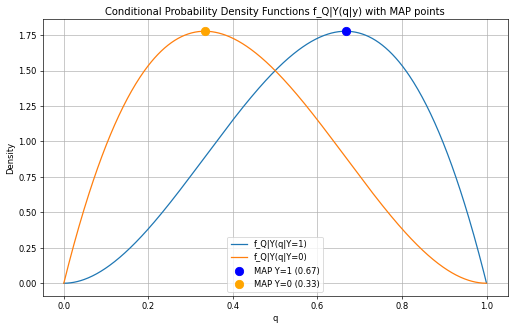

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the conditional PDFs
def f_Q_given_Y_1(q):
    return 12 * q**2 * (1 - q)

def f_Q_given_Y_0(q):
    return 12 * q * (1 - q)**2

# Generate q values from 0 to 1
q_values = np.linspace(0, 1, 500)

# Calculate the corresponding PDF values
pdf_y1 = [f_Q_given_Y_1(q) for q in q_values]
pdf_y0 = [f_Q_given_Y_0(q) for q in q_values]

# Get MAP values (already calculated in cell 45458c60)
# If this cell were run independently, we'd need to re-calculate or import them.
# For the purpose of modifying this cell, I'll assume map_y1 and map_y0 are available or re-derive them if necessary within this cell, but for now, I'll just use the variable names.

# Define MAP values (assuming they are already computed or available in the kernel)
# For robustness, let's include the calculations here as well, if this cell was to be run standalone.
map_y1 = 2/3
map_y0 = 1/3

# Calculate PDF values at MAP points
map_pdf_y1 = f_Q_given_Y_1(map_y1)
map_pdf_y0 = f_Q_given_Y_0(map_y0)

# Plotting
plt.figure(figsize=(10, 6), dpi =60)
sns.lineplot(x=q_values, y=pdf_y1, label='f_Q|Y(q|Y=1)')
sns.lineplot(x=q_values, y=pdf_y0, label='f_Q|Y(q|Y=0)')

# Add MAP points to the plot
plt.scatter([map_y1], [map_pdf_y1], color='blue', marker='o', s=100, zorder=5, label=f'MAP Y=1 ({map_y1:.2f})')
plt.scatter([map_y0], [map_pdf_y0], color='orange', marker='o', s=100, zorder=5, label=f'MAP Y=0 ({map_y0:.2f})')

plt.title('Conditional Probability Density Functions f_Q|Y(q|y) with MAP points')
plt.xlabel('q') ; plt.ylabel('Density') ; plt.legend()
plt.grid(True) ; plt.show()

### Maximum A Posteriori (MAP) Calculation

To find the Maximum A Posteriori (MAP) for a probability density function, we need to find the mode of the distribution. This is done by taking the derivative of the PDF with respect to the variable, setting it to zero, and solving for the variable.

#### 1. For $f_{Q|Y}(q|Y=1)$ (given success):

The conditional PDF is given by:
$ f_{Q|Y}(q|Y=1) = 12q^2(1-q) = 12q^2 - 12q^3 $

To find the mode, we take the derivative with respect to $q$ and set it to zero $ \frac{\mathrm{d}}{\mathrm{d}q} (12q^2 - 12q^3) = 24q - 36q^2 $

Set the derivative to zero $ 24q - 36q^2 = 0 $
Factor out $12q$, $ 12q(2 - 3q) = 0 $

This gives two possible solutions
- $ q = 0 \quad \text{or} \quad 2 - 3q = 0 \implies 3q = 2 \implies q = \frac{2}{3} $

Considering the domain $0 \le q \le 1$, the peak (MAP) is at $ \text{MAP for } Y=1: q = \frac{2}{3} $

#### 2. For $f_{Q|Y}(q|Y=0)$ (given failure):

The conditional PDF is given by $ f_{Q|Y}(q|Y=0) = 12q(1-q)^2 $.

Expand the expression $ 12q(1-q)^2 = 12q(1 - 2q + q^2) = 12q - 24q^2 + 12q^3 $

To find the mode, we take the derivative with respect to $q$ and set it to zero, $ \frac{\mathrm{d}}{\mathrm{d}q} (12q - 24q^2 + 12q^3) = 12 - 48q + 36q^2 $

Set the derivative to zero $ 12 - 48q + 36q^2 = 0 $.
Divide by 12 to simplify $ 3q^2 - 4q + 1 = 0 $.

Use the quadratic formula $q = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$:
- $ q = \frac{-(-4) \pm \sqrt{(-4)^2 - 4(3)(1)}}{2(3)} = \frac{4 \pm \sqrt{16 - 12}}{6} = \frac{4 \pm \sqrt{4}}{6} = \frac{4 \pm 2}{6} $

This gives two possible solutions:
- $ q = \frac{4+2}{6} = \frac{6}{6} = 1 \quad \text{or} \quad q = \frac{4-2}{6} = \frac{2}{6} = \frac{1}{3} $

Considering the domain $0 \le q \le 1$, the peak (MAP) is at $ \text{MAP for } Y=0: q = \frac{1}{3} $

### Derivations

A random variable X is generated based on a coin flip:
- With probability $p$ (Heads), X is uniform on [0,1], so $f_{X|H}(x) = 1$ for $0 \le x \le 1$.
- With probability $(1-p)$ (Tails), X has PDF $f_{X|T}(x) = 2x$ for $0 \le x \le 1$.

PDF $f_X(x)$, by the law of total probability:
$f_X(x) = P(\text{H}) \cdot f_{X|H}(x) + P(\text{T}) \cdot f_{X|T}(x)$
- $f_X(x) = p \cdot 1 + (1-p) \cdot 2x = p + 2x(1-p)$ for $0 \le x \le 1$

$E[X] = \int_0^1 x \cdot f_X(x) \mathrm{d}x = \int_0^1 x(p + 2x(1-p)) \mathrm{d}x = \int_0^1 (px + 2x^2(1-p)) \mathrm{d}x$
- $E[X] = \left[ \frac{p}{2}x^2 + \frac{2(1-p)}{3}x^3 \right]_0^1 = \frac{p}{2} + \frac{2(1-p)}{3}$

This can also be calculated as $E[X] = P(\text{H})E[X|H] + P(\text{T})E[X|T]$.
$E[X|H] = \int_0^1 x \cdot 1 \mathrm{d}x = \left[ \frac{1}{2}x^2 \right]_0^1 = \frac{1}{2}$
$E[X|T] = \int_0^1 x \cdot 2x \mathrm{d}x = \int_0^1 2x^2 \mathrm{d}x = \left[ \frac{2}{3}x^3 \right]_0^1 = \frac{2}{3}$
- $E[X] = p \cdot \frac{1}{2} + (1-p) \cdot \frac{2}{3}$

Conditional Probability $P(\text{Tails} | X = x)$ by Bayes' theorem:
- $P(\text{T} | X = x) = \frac{f_{X|T}(x) P(\text{T})}{f_X(x)} = \frac{2x(1-p)}{p + 2x(1-p)}$
For $x = 1/4$ and $p = 0.5$:
- $P(\text{T} | X = 1/4) = \frac{2(1/4)(1-0.5)}{0.5 + 2(1/4)(1-0.5)} = \frac{0.5 \cdot 0.5}{0.5 + 0.5 \cdot 0.5} = \frac{0.25}{0.5 + 0.25} = \frac{0.25}{0.75} = \frac{1}{3}$

MAP Rule

The MAP rule decides Heads if $P(\text{H} | X=x) > P(\text{T} | X=x)$, and Tails otherwise.
$P(\text{H} | X = x) = \frac{f_{X|H}(x) P(\text{H})}{f_X(x)} = \frac{1 \cdot p}{p + 2x(1-p)}$

We decide Heads if $\frac{p}{p + 2x(1-p)} > \frac{2x(1-p)}{p + 2x(1-p)}$
Since the denominator is positive for $0 \le x \le 1$, we can simplify to:
$p > 2x(1-p)$
$x < \frac{p}{2(1-p)}$
So, the threshold $a = \frac{p}{2(1-p)}$.
If $p = 0.5$, then $a = \frac{0.5}{2(1-0.5)} = \frac{0.5}{2(0.5)} = \frac{0.5}{1} = 0.5$.
Thus, if $p=0.5$, Heads is chosen if $X < 0.5$, and Tails if $X > 0.5$. This matches the user's $a = 1/2$.

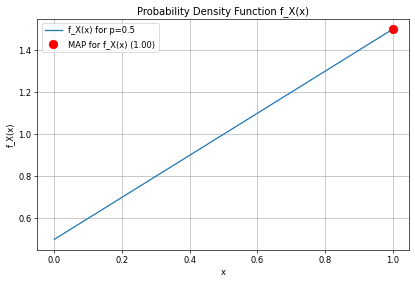

Symbolic E[X] = 2/3 - p/6
E[X] for p=0.5 = 0.5833
Symbolic E[X] (alternative) = 2/3 - p/6
E[X] (alternative) for p=0.5 = 0.5833

P(Tails | X = 0.25) for p=0.5 = 0.3333

MAP threshold 'a' for p=0.5 = 0.5000
MAP threshold 'a' for p=0.5 = 0.5000


In [ ]:
from sympy import integrate, Symbol

# Define the probability p for Heads
p = 0.5

# Define the PDF f_X(x)
def f_X(x, p_head):
    if 0 <= x <= 1:
        return p_head + 2 * x * (1 - p_head)
    return 0

# x values for plotting
x_values = np.linspace(0, 1, 500)
# Calculate f_X(x) values
pdf_X_values = [f_X(val, p) for val in x_values]

# Determine MAP for f_X(x)
# For f_X(x) = p + 2x(1-p), with p=0.5, f_X(x) = 0.5 + x.
# This is an increasing function on [0,1], so the max is at x=1.
map_x_val = 1.0
map_f_x_val = f_X(map_x_val, p)
plt.scatter([map_x_val], [map_f_x_val], color='red', marker='o', s=100, zorder=5, label=f'MAP for f_X(x) ({map_x_val:.2f})')

# Define symbolic variable
x_sym = Symbol('x') ; p_sym = Symbol('p')

# Calculate E[X]
# Using the derived f_X(x)
f_X_sym = p_sym + 2 * x_sym * (1 - p_sym)
E_X_sym = integrate(x_sym * f_X_sym, (x_sym, 0, 1))

# Substitute p = 0.5
E_X_val = E_X_sym.subs(p_sym, p)
# Verify with alternative calculation: p*E[X|H] + (1-p)*E[X|T]
E_X_given_H = integrate(x_sym * 1, (x_sym, 0, 1))
E_X_given_T = integrate(x_sym * (2 * x_sym), (x_sym, 0, 1))

E_X_alt_sym = p_sym * E_X_given_H + (1 - p_sym) * E_X_given_T
E_X_alt_val = E_X_alt_sym.subs(p_sym, p)

# Calculate P(Tails | X = 1/4)
def P_Tails_given_X(x_val, p_head):
    f_X_given_T = 2 * x_val # for 0 <= x_val <= 1
    P_Tails = (1 - p_head)
    f_X_val = f_X(x_val, p_head)
    if f_X_val == 0:
        return 0
    return (f_X_given_T * P_Tails) / f_X_val

x_test = 1/4
P_Tails_val = P_Tails_given_X(x_test, p)
print(f"\nP(Tails | X = {x_test}) for p={p} = {P_Tails_val:.4f}")

# Determine the MAP rule (threshold 'a')
# MAP rule decides Heads if P(Heads | X=x) > P(Tails | X=x)
# This simplifies to p > 2x(1-p)
# So, x < p / (2*(1-p))
def calculate_map_threshold(p_head):
    if p_head == 1:
        return 1 # If p=1, always Heads, X~U(0,1).  Tails probability is 0.
    if p_head == 0:
        return 0 # If p=0, always Tails, X~2x. Heads probability is 0.
    return p_head / (2 * (1 - p_head))

a_threshold = calculate_map_threshold(p)
# Test with user's specific value
p_user = 1/2
a_user_threshold = calculate_map_threshold(p_user)
print(f"\nMAP threshold 'a' for p={p} = {a_threshold:.4f}")
print(f"MAP threshold 'a' for p={p_user} = {a_user_threshold:.4f}")

### Sum of Independent Normal Random Variables

If we have two independent normal random variables:

-   $X \sim N(\mu_x, \sigma_x^2)$ $\quad$ $Y \sim N(\mu_y, \sigma_y^2)$

Their probability density functions (PDFs) are
- $f_X(x) = \frac{1}{\sqrt{2\pi}\sigma_x} \exp\left(-\frac{(x-\mu_x)^2}{2\sigma_x^2}\right)$  $\quad$
$f_Y(y) = \frac{1}{\sqrt{2\pi}\sigma_y} \exp\left(-\frac{(y-\mu_y)^2}{2\sigma_y^2}\right)$

The PDF of their sum, $Z = X + Y$, is given by the convolution of their individual PDFs
- $f_Z(z) = \int_{-\infty}^{\infty} f_X(x) f_Y(z - x) \mathrm{d}x$

The result of this convolution is also a normal distribution $f_Z(z) = \frac{1}{\sqrt{2\pi}(\sigma_x^2 + \sigma_y^2)} \exp\left(-\frac{(z - \mu_x - \mu_y)^2}{2(\sigma_x^2 + \sigma_y^2)}\right)$

Thus, the sum $Z$ is also normally distributed with:
- $Z \sim N(\mu_x + \mu_y, \sigma_x^2 + \sigma_y^2)$



Parameters for X: Mean = 5, Std Dev = 2
Parameters for Y: Mean = 10, Std Dev = 3
Expected Parameters for Z (X+Y): Mean = 15, Variance = 13, Std Dev = 3.61


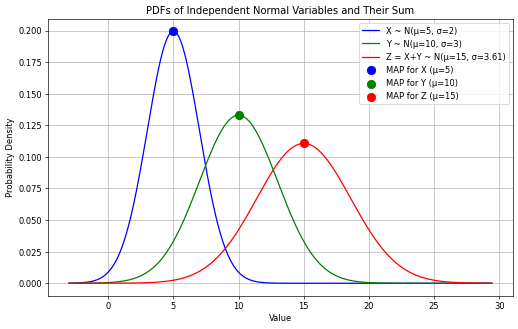

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for two independent normal random variables
mu_x, sigma_x = 5, 2  # Mean and standard deviation for X
mu_y, sigma_y = 10, 3 # Mean and standard deviation for Y

# Calculate parameters for the sum Z = X + Y
mu_z = mu_x + mu_y
sigma_z_squared = sigma_x**2 + sigma_y**2
sigma_z = np.sqrt(sigma_z_squared)

print(f"Parameters for X: Mean = {mu_x}, Std Dev = {sigma_x} \n"
f"Parameters for Y: Mean = {mu_y}, Std Dev = {sigma_y} \n"
f"Expected Parameters for Z (X+Y): Mean = {mu_z}, Variance = {sigma_z_squared}, Std Dev = {sigma_z:.2f}")

# Define a common range for plotting that covers all distributions
min_val = min(mu_x - 4*sigma_x, mu_y - 4*sigma_y, mu_z - 4*sigma_z)
max_val = max(mu_x + 4*sigma_x, mu_y + 4*sigma_y, mu_z + 4*sigma_z)
x_vals = np.linspace(min_val, max_val, 500)

# Calculate PDFs for X, Y, and Z
pdf_x = norm.pdf(x_vals, mu_x, sigma_x)
pdf_y = norm.pdf(x_vals, mu_y, sigma_y)
pdf_z = norm.pdf(x_vals, mu_z, sigma_z)

# Plotting
plt.figure(figsize=(10, 6), dpi=60)

# Plot PDFs
plt.plot(x_vals, pdf_x, label=f'X ~ N(μ={mu_x}, σ={sigma_x})', color='blue')
plt.plot(x_vals, pdf_y, label=f'Y ~ N(μ={mu_y}, σ={sigma_y})', color='green')
plt.plot(x_vals, pdf_z, label=f'Z = X+Y ~ N(μ={mu_z}, σ={sigma_z:.2f})', color='red')

# Mark MAP points (means for normal distributions)
plt.scatter(mu_x, norm.pdf(mu_x, mu_x, sigma_x), color='blue', marker='o', s=100, zorder=5, label=f'MAP for X (μ={mu_x})')
plt.scatter(mu_y, norm.pdf(mu_y, mu_y, sigma_y), color='green', marker='o', s=100, zorder=5, label=f'MAP for Y (μ={mu_y})')
plt.scatter(mu_z, norm.pdf(mu_z, mu_z, sigma_z), color='red', marker='o', s=100, zorder=5, label=f'MAP for Z (μ={mu_z})')

plt.title('PDFs of Independent Normal Variables and Their Sum')
plt.xlabel('Value') ; plt.ylabel('Probability Density')
plt.legend() ; plt.grid(True) ; plt.show()

### Derived Distribution - Convolution Formula and Mechanics

Given two independent random variables:
- $X \sim N(\mu_x, \sigma_x^2)$ $\quad$ $Y \sim N(\mu_y, \sigma_y^2)$

The PDF of the sum $Z = X + Y$ can be found using convolution. If we consider the conditional PDF of $Z$ given $X=x$, $f_{Z|X}(z |x) = f_Y(z -x)$

The joint PDF of $Z$ and $X$ is
- $f_{Z,X}(z, x) = f_X(x) \cdot f_{Z|X}(z |x) = f_X(x) \cdot f_Y(z -x)$

For the marginal PDF of $Z$, we integrate over $X$
- $f_Z(z) = \int_{-\infty}^{\infty} f_X(x) f_Y(z -x) \mathrm{d}x$

This is the general convolution formula for the sum of two independent continuous random variables.

For discrete random variables, the analogous formula is a summation
- $p_Z(z) = \sum_x p_X(x) p_Y(z -x)$

#### Sum of Two Uniform Random Variables

Two independent uniform distributions, $X \sim U(0,1)$$X \sim U(0,1)$ and $Y \sim U(0,1)$$Y \sim U(0,1)$, as an example. Their sum $Z = X+Y$$Z = X+Y$ will follow a triangular distribution.

The plot will show the PDFs of X, Y, and their sum Z. The concept of $X+Y = constant$ is inherently visualized in the convolution integral, where we sum products of $f_X(x)$$f_X(x)$ and $f_Y(z-x)$$f_Y(z-x)$ for a constant sum z. The resulting line for $f_Z(z)$$f_Z(z)$ on the plot represents the probability density for each possible constant sum z.

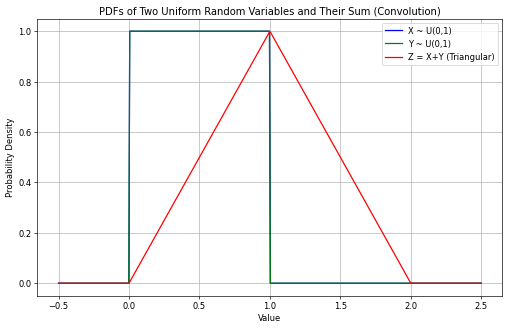

In [ ]:
# Define parameters for two independent uniform random variables
# X ~ U(0, 1), Y ~ U(0, 1)

# PDF for X
def pdf_x(x):
    return uniform.pdf(x, loc=0, scale=1)

# PDF for Y
def pdf_y(y):
    return uniform.pdf(y, loc=0, scale=1)

# PDF for Z = X + Y (convolution of two U(0,1) distributions is a triangular distribution)
def pdf_z(z):
    if 0 <= z <= 1:
        return z
    elif 1 < z <= 2:
        return 2 - z
    else:
        return 0

# Generate x_vals for plotting
x_vals = np.linspace(-0.5, 2.5, 500)

# Calculate PDFs
pdfs_x = [pdf_x(val) for val in x_vals]
pdfs_y = [pdf_y(val) for val in x_vals]
pdfs_z = [pdf_z(val) for val in x_vals]

Show the convolution of two uniform distributions with different ranges. For instance, if X ~ U(0,1) and Y ~ U(0,2), their sum Z = X+Y will result in a trapezoidal distribution. This PDF will feature both linear increasing/decreasing segments and a flat, constant segment in the middle, which should align with your idea of 'constant (let's say a line)'.

The individual uniform distributions X and Y are flat over their respective ranges. However, their convolution (sum Z) results in a trapezoidal distribution. The PDF of Z starts linearly increasing from 0, then maintains a constant probability density between 1 and 2, and finally decreases linearly back to 0. This 'constant' flat segment between 1 and 2, along with the linear segments, fulfills the idea of having a 'line' or constant part in the resulting sum's PDF, which is a key characteristic when summing uniform distributions with differing ranges.

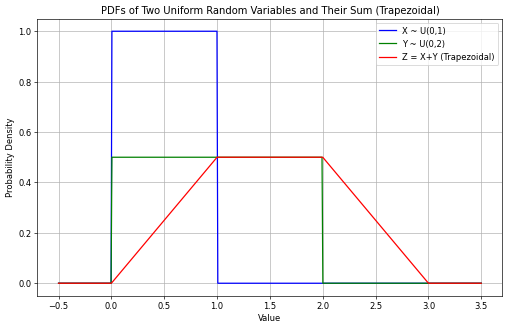

In [ ]:
# Define parameters for two independent uniform random variables
# X ~ U(0, 1), Y ~ U(0, 2)
# The sum Z = X + Y will have a trapezoidal distribution

# PDF for X
def pdf_x_new(x):
    return uniform.pdf(x, loc=0, scale=1) # U(0,1)

# PDF for Y
def pdf_y_new(y):
    return uniform.pdf(y, loc=0, scale=2) # U(0,2)

# PDF for Z = X + Y (convolution of U(0,1) and U(0,2) is a trapezoidal distribution)
def pdf_z_trapezoid(z):
    if 0 <= z < 1:
        return z / 2
    elif 1 <= z < 2:
        return 0.5
    elif 2 <= z <= 3:
        return (3 - z) / 2
    else:
        return 0

# Generate x_vals for plotting
x_vals_new = np.linspace(-0.5, 3.5, 500) # Adjust range to cover U(0,1) + U(0,2)

# Calculate PDFs
pdfs_x_new = [pdf_x_new(val) for val in x_vals_new]
pdfs_y_new = [pdf_y_new(val) for val in x_vals_new]
pdfs_z_new = [pdf_z_trapezoid(val) for val in x_vals_new]

Transformations and Linear Combinations of Random Variables, extending on the concept of convolution to more complex linear combinations of independent random variables.

#### 1. Difference of Random Variables: $X - Y$

The difference between two independent random variables, $X$ and $Y$, can be expressed as a sum: $X - Y = X + (-Y)$.

For the PDF of $-Y$, we use the transformation rule for a scaled random variable $Z = aY$. The PDF of $Z$ is given by
- $f_Z(z) = \frac{1}{|a|} f_Y\left(\frac{z}{a}\right)$

For $Z = -Y$ (where $a = -1$)
- $f_{-Y}(y') = \frac{1}{|-1|} f_Y\left(\frac{y'}{-1}\right) = f_Y(-y')$

If $Y \sim N(\mu_y, \sigma_y^2)$, then $-Y \sim N(-\mu_y, \sigma_y^2)$. Once we have $f_X(x)$ and $f_{-Y}(y')$, we can use the convolution formula for their sum to find $f_{X-Y}(z)$
- $f_{X-Y}(z) = \int_{-\infty}^{\infty} f_X(x) f_{-Y}(z - x) \mathrm{d}x$

If $X \sim N(\mu_x, \sigma_x^2)$ and $Y \sim N(\mu_y, \sigma_y^2)$, then $X-Y \sim N(\mu_x - \mu_y, \sigma_x^2 + \sigma_y^2)$.

#### 2. Linear Combination: $aX + Y$

Similarly, for a linear combination like $aX + Y$, we first find the PDF of $aX$. For $Z = aX$, $f_{aX}(x') = \frac{1}{|a|} f_X\left(\frac{x'}{a}\right)$

If $X \sim N(\mu_x, \sigma_x^2)$, then $aX \sim N(a\mu_x, (a\sigma_x)^2)$. Then, we use the convolution formula for the sum of $aX$ and $Y$
- $f_{aX+Y}(z) = \int_{-\infty}^{\infty} f_{aX}(x') f_Y(z - x') \mathrm{d}x'$

If $X \sim N(\mu_x, \sigma_x^2)$ and $Y \sim N(\mu_y, \sigma_y^2)$, then $aX+Y \sim N(a\mu_x + \mu_y, (a\sigma_x)^2 + \sigma_y^2)$.

### Summary of Linear Combinations of Independent Normal Random Variables

Given two independent normal random variables:
- $X \sim N(\mu_x, \sigma_x^2)$
- $Y \sim N(\mu_y, \sigma_y^2)$

#### 1. Difference of Random Variables: $X - Y$

If $X - Y$ is considered, the resulting distribution is also normal:
$X - Y \sim N(\mu_x - \mu_y, \sigma_x^2 + \sigma_y^2)$

*   **Example Parameters:**
    *   $X \sim N(10, 2^2=4)$
    *   $Y \sim N(5, 3^2=9)$
    *   $X - Y \sim N(10 - 5, 4 + 9) = N(5, 13)$

#### 2. Linear Combination: $aX + bY$

For a general linear combination $aX + bY$, the resulting distribution is also normal:
$aX + bY \sim N(a\mu_x + b\mu_y, (a\sigma_x)^2 + (b\sigma_y)^2)$

In our specific example, for $2X + Y$ (where $a=2, b=1$):
*   **Example Parameters:**
    *   $X \sim N(10, 2^2=4)$
    *   $Y \sim N(5, 3^2=9)$
    *   $2X \sim N(2 \times 10, (2 \times 2)^2) = N(20, 16)$
    *   $2X + Y \sim N(20 + 5, 16 + 9) = N(25, 25)$

Parameters for X: Mean = 10, Std Dev = 2
Parameters for Y: Mean = 5, Std Dev = 3
Expected Parameters for X - Y: Mean = 5, Variance = 13, Std Dev = 3.61

Parameters for 2X: Mean = 20, Std Dev = 4
Expected Parameters for 2X + Y: Mean = 25, Variance = 25, Std Dev = 5.00



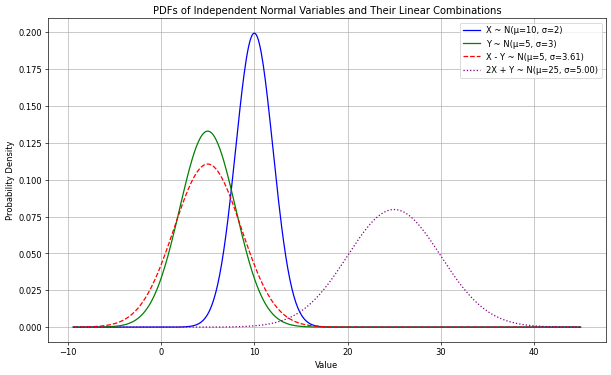

In [ ]:
# Define parameters for X and Y
mu_x, sigma_x = 10, 2  # X ~ N(10, 2^2)
mu_y, sigma_y = 5, 3   # Y ~ N(5, 3^2)

# Calculate parameters for X - Y (as X + (-Y))
# Parameters for -Y
mu_neg_y = -mu_y
sigma_neg_y = sigma_y # Standard deviation remains positive

# Parameters for X - Y
mu_x_minus_y = mu_x + mu_neg_y
sigma_x_minus_y_squared = sigma_x**2 + sigma_neg_y**2
sigma_x_minus_y = np.sqrt(sigma_x_minus_y_squared)

# Calculate parameters for 2X + Y
# Parameters for 2X
a = 2
mu_2x = a * mu_x
sigma_2x = abs(a) * sigma_x # Std dev scales by |a|

# Parameters for 2X + Y
mu_2x_plus_y = mu_2x + mu_y
sigma_2x_plus_y_squared = sigma_2x**2 + sigma_y**2
sigma_2x_plus_y = np.sqrt(sigma_2x_plus_y_squared)

# Define a common range for plotting
min_val = min(mu_x - 4*sigma_x, mu_y - 4*sigma_y, mu_x_minus_y - 4*sigma_x_minus_y, mu_2x_plus_y - 4*sigma_2x_plus_y)
max_val = max(mu_x + 4*sigma_x, mu_y + 4*sigma_y, mu_x_minus_y + 4*sigma_x_minus_y, mu_2x_plus_y + 4*sigma_2x_plus_y)
x_vals = np.linspace(min_val, max_val, 500)

# Calculate PDFs
pdf_x = norm.pdf(x_vals, mu_x, sigma_x)
pdf_y = norm.pdf(x_vals, mu_y, sigma_y)
pdf_x_minus_y = norm.pdf(x_vals, mu_x_minus_y, sigma_x_minus_y)
pdf_2x_plus_y = norm.pdf(x_vals, mu_2x_plus_y, sigma_2x_plus_y)

#### Scenario: $Z = X + Y$ where $Y = |X|$ (Dependent Variables)

In this scenario, $X$ and $Y$ are dependent random variables, as $Y$ is a function of $X$. Specifically, $Z = X + |X|$.

Let's consider $X \sim N(0, 1)$ (Standard Normal Distribution) to see how $Z$ behaves:

-   If $X \ge 0$, then $|X| = X$, so $Z = X + X = 2X$.
-   If $X < 0$, then $|X| = -X$, so $Z = X + (-X) = 0$.

This means that for all negative values of $X$, $Z$ will be exactly 0. For positive values of $X$, $Z$ will be twice the value of $X$. The resulting distribution of $Z$ will therefore have a significant concentration (a point mass) at $Z=0$, and then a continuous distribution for $Z > 0$ that is a scaled version of the positive half of $X$'s distribution.

#### Analytical PDFs for Dependent Variables: $X \sim N(0,1)$, $Y=|X|$, and $Z=X+|X|$

As previously discussed, for $X \sim N(0,1)$, the distributions of $Y=|X|$ and $Z=X+|X|$ are derived as follows:

#### 1. PDF of $X$:
Given $X \sim N(0,1)$, its Probability Density Function (PDF) is:
$f_X(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$

#### 2. PDF of $Y=|X|$ (Folded Normal Distribution):
For $Y = |X|$, where $X \sim N(0,1)$, the PDF of $Y$ is a folded normal distribution. Since $N(0,1)$ is symmetric around 0:
$f_Y(y) = 2 \cdot f_X(y) = 2 \cdot \frac{1}{\sqrt{2\pi}} e^{-y^2/2} \quad \text{for } y \ge 0$
$f_Y(y) = 0 \quad \text{for } y < 0$

#### 3. PDF of $Z=X+|X|$:
The PDF of $Z$ has two distinct parts:
*   **Point Mass at $Z=0$:** When $X < 0$, $Z = X + (-X) = 0$. The probability of this event is $P(Z=0) = P(X < 0) = 0.5$ for $X \sim N(0,1)$. This is a discrete probability mass, which cannot be represented by a continuous PDF curve directly; it would require a Dirac delta function.

*   **Continuous Part for $Z>0$:** When $X \ge 0$, $Z = X + X = 2X$. Using the change of variable formula, if $Z = 2X$, then $X = Z/2$ and $dX/dZ = 1/2$. The PDF for $Z > 0$ is:
    $f_Z(z) = f_X(z/2) \cdot |\frac{dX}{dZ}| = \frac{1}{\sqrt{2\pi}} e^{-(z/2)^2/2} \cdot \frac{1}{2} = \frac{1}{2\sqrt{2\pi}} e^{-z^2/8} \quad \text{for } z > 0$

When plotting these as continuous lines, we will represent the continuous part of $f_Z(z)$ for $z>0$ and use an annotation to highlight the probability mass at $Z=0$.


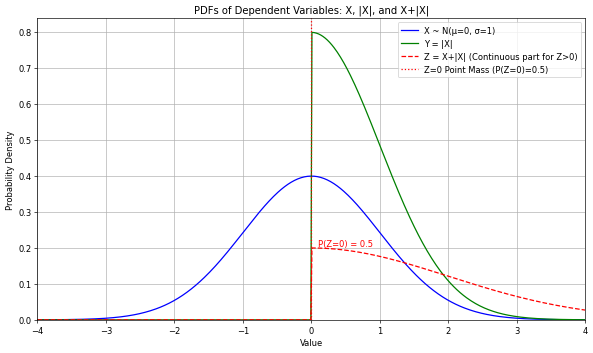

In [ ]:
# Define parameters for X (Standard Normal Distribution)
mu_x, sigma_x = 0, 1  # X ~ N(0, 1)

# Define the range for plotting
x_vals = np.linspace(-4, 4, 500) # Range for X

# Calculate PDF for X
pdf_x = norm.pdf(x_vals, mu_x, sigma_x)

# Calculate PDF for Y = |X| (Folded Normal Distribution)
# f_Y(y) = 2 * f_X(y) for y >= 0
y_vals = np.linspace(-4, 4, 500)
pdf_y = np.where(y_vals >= 0, 2 * norm.pdf(y_vals, mu_x, sigma_x), 0)

# Calculate PDF for Z = X + |X|
# For Z > 0, f_Z(z) = 0.5 * f_X(z/2)
# For Z = 0, there is a probability mass P(X < 0) = 0.5
z_vals = np.linspace(-4, 4, 500)
pdf_z = np.where(z_vals > 0, 0.5 * norm.pdf(z_vals / 2, mu_x, sigma_x), 0)

#### Scenario: $Z = X + Y$ where $Y = X$ for Heads and $Y = -X$ for Tails (Dependent Variables)

Given $X \sim N(0, 1)$ (Standard Normal Distribution) and $Y$ is defined as:
- If **Heads**: $Y = X$, so $Z = X + X = 2X$.
- If **Tails**: $Y = -X$, so $Z = X + (-X) = 0$.

#### Analytical PDFs for Dependent Variables: $X \sim N(0,1)$, $Y$ (conditional on coin), and $Z=X+Y$

#### 1. PDF of $X$:
Given $X \sim N(0,1)$, its Probability Density Function (PDF) is:
$f_X(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$

#### 2. PDF of $Z=X+Y$:
The PDF of $Z$ has two distinct parts:

*   **Point Mass at $Z=0$:** When the coin flip is **Tails**, $Z = X + (-X) = 0$. The probability of this event is $P(Z=0) = P(\text{Tails}) = 0.5$. This is a discrete probability mass, which cannot be represented by a continuous PDF curve directly; it requires a Dirac delta function.

*   **Continuous Part for $Z>0$ (or $Z<0$ depending on $X$):** When the coin flip is **Heads**, $Z = X + X = 2X$.

Using the change of variable formula for the continuous part ($Z = 2X$), if $Z = 2X$, then $X = Z/2$ and $dX/dZ = 1/2$. The PDF for $Z$ coming from this case is:
- $f_{2X}(z) = f_X(z/2) \cdot |\frac{dX}{dZ}| = \frac{1}{\sqrt{2\pi}} e^{-(z/2)^2/2} \cdot \frac{1}{2} = \frac{1}{2\sqrt{2\pi}} e^{-z^2/8}$

Since this continuous part occurs with probability $P(\text{Heads})=0.5$, the contribution to the overall PDF of $Z$ is $0.5 \cdot f_{2X}(z)$ for $z \ne 0$.

Combining both parts, the distribution of $Z$ is a mixed distribution, with a probability mass at $Z=0$ and a continuous part elsewhere. This result is identical to the $X + |X|$ case when $X \sim N(0,1)$, demonstrating how different dependencies can lead to similar resulting distributions.

Let $X$ be a random variable, and let $C$ be a random variable representing a coin flip, independent of $X$.

Definition of Y based on a coin flip
$Y = g(X, C) = \begin{cases}
    X & \text{if } C=1 \text{(H)} \\
    -X & \text{if } C=0 \text{ (T)})
\end{cases}$

$X \sim N(\mu, \sigma^2)$

CDF of a standard normal, i.e. let $Z \sim N(0,1)$ be a standard normal random variable. Its CDF is denoted by $\Phi(z)$:
$\Phi(z) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{z} \exp\left(-\frac{t^2}{2}\right) \mathrm{d}t$

Standardization of X and its CDF:
The probability $P(X \le x)$ can be expressed using the standard normal CDF:
$P(X \le x) = P\left(\frac{X - \mu}{\sigma} \le \frac{x - \mu}{\sigma}\right) = \Phi\left(\frac{x - \mu}{\sigma}\right)$

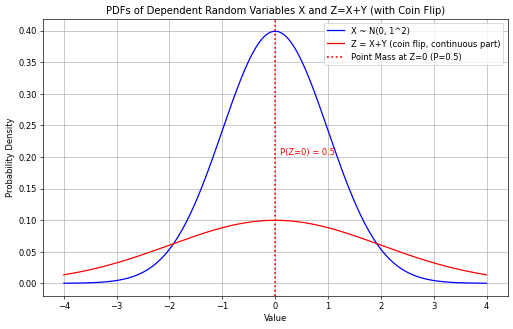

In [ ]:
# Define parameters for X (Standard Normal Distribution)
mu_x, sigma_x = 0, 1  # X ~ N(0, 1)

# Define the range for plotting
x_vals = np.linspace(-4, 4, 500) # Range for X

# Calculate PDF for X
pdf_x = norm.pdf(x_vals, mu_x, sigma_x)

# Calculate PDF for Z = X + Y (where Y is X for Heads, -X for Tails)
# P(Z=0) = P(Tails) = 0.5
# For Z != 0, Z = 2X with P(Heads) = 0.5
# f_Z(z) = 0.5 * f_{2X}(z) = 0.5 * f_X(z/2) * (1/2) = 0.25 * f_X(z/2)

z_vals = np.linspace(-4, 4, 500)
pdf_z_continuous_part = np.where(z_vals != 0, 0.25 * norm.pdf(z_vals / 2, mu_x, sigma_x), 0)

# Plotting
plt.figure(figsize=(10, 6), dpi=60)

# Plot PDFs
plt.plot(x_vals, pdf_x, label=f'X ~ N({mu_x}, {sigma_x}^2)', color='blue')
plt.plot(z_vals, pdf_z_continuous_part, label=f'Z = X+Y (coin flip, continuous part)', color='red')

# Annotate the point mass at Z=0
plt.axvline(x=0, color='red', linestyle=':', linewidth=2, label='Point Mass at Z=0 (P=0.5)')
plt.text(0.1, 0.2, 'P(Z=0) = 0.5', color='red', verticalalignment='bottom')

plt.title('PDFs of Dependent Random Variables X and Z=X+Y (with Coin Flip)')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

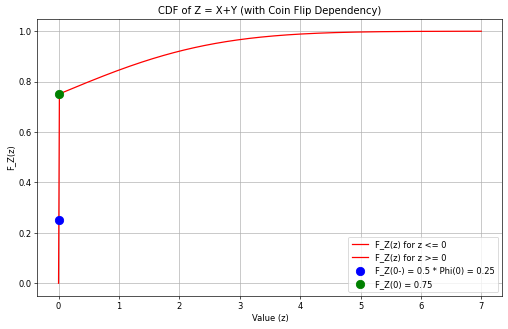

In [ ]:
# Define parameters for X (Standard Normal Distribution)
mu_x, sigma_x = 0, 1  # X ~ N(0, 1)

# Define the range for plotting (reusing z_vals from previous cells if available)
# Ensure z_vals covers the relevant range including 0
if 'z_vals' not in locals() or 'z_vals' not in globals():
    z_vals = np.linspace(-4, 4, 500)

# CDF for Z = X + Y (with coin flip dependency)
cdf_z = np.zeros_like(z_vals)

# For z < 0: F_Z(z) = 0.5 * Phi(z/2)
cdf_z[z_vals < 0] = 0.5 * norm.cdf(z_vals[z_vals < 0] / 2, mu_x, sigma_x)

# At z = 0: F_Z(0) = 0.75 (due to the point mass)
# Note: This will create a jump in the plot. We'll handle it by plotting two segments.

# For z > 0: F_Z(z) = 0.5 * Phi(z/2) + 0.5
cdf_z[z_vals > 0] = 0.5 * norm.cdf(z_vals[z_vals > 0] / 2, mu_x, sigma_x) + 0.5

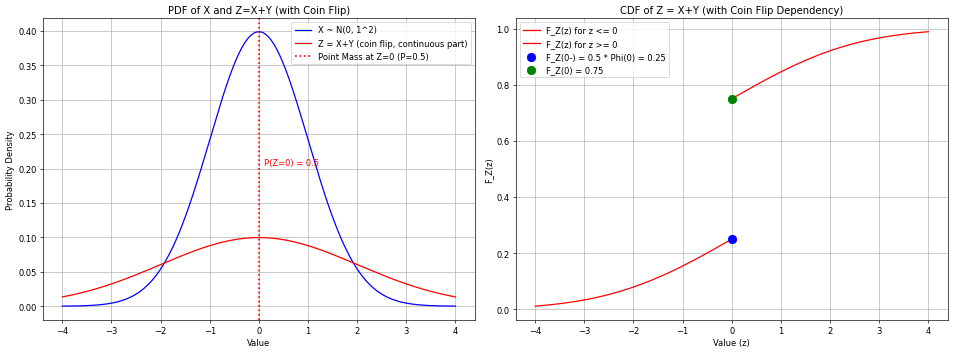

In [ ]:
# Define parameters for X (Standard Normal Distribution)
mu_x, sigma_x = 0, 1  # X ~ N(0, 1)

# Define the range for plotting
x_vals = np.linspace(-4, 4, 500) # Range for X and Z

# PDF Calculation for Z = X+Y (with coin flip)
# P(Z=0) = P(Tails) = 0.5
# For Z != 0, Z = 2X with P(Heads) = 0.5
# f_Z(z) = 0.5 * f_{2X}(z) = 0.5 * f_X(z/2) * (1/2) = 0.25 * f_X(z/2)
pdf_z_continuous_part = np.where(x_vals != 0, 0.25 * norm.pdf(x_vals / 2, mu_x, sigma_x), 0)
# CDF Calculation for Z = X+Y (with coin flip)
cdf_z = np.zeros_like(x_vals)
# For z < 0: F_Z(z) = 0.5 * Phi(z/2)
cdf_z[x_vals < 0] = 0.5 * norm.cdf(x_vals[x_vals < 0] / 2, mu_x, sigma_x)
# For z > 0: F_Z(z) = 0.5 * Phi(z/2) + 0.5
cdf_z[x_vals > 0] = 0.5 * norm.cdf(x_vals[x_vals > 0] / 2, mu_x, sigma_x) + 0.5

For X ~ N(0,1), the covariance $Cov(X,Y) = 0$ shows  a case where $X$ and $Y$ are clearly dependent, but their covariance is zero, highlighting that zero covariance only implies the absence of a *linear* relationship, not necessarily independence.

Even with a general normal distribution $X \sim N(\mu, \sigma^2)$, the covariance $Cov(X,Y) = 0$. This result holds because the dependency of $Y$ on $X$ is symmetric around the origin (for $Y=-X$) and directly proportional (for $Y=X$), and the probabilities of these two cases are equal.

#### Multiple random variables

A function of multiple random variables (r.v.'s) $Z = g(X, Y)$, where $Z = Y/X$.

Let $X, Y$ be independent random variables, uniformly distributed on $[0,1]$.

The Probability Density Function (PDF) $f_Z(z)$ and Cumulative Distribution Function (CDF) $F_Z(z)$ for $Z = Y/X$ are given as:

$F_Z(z) = P(Y/X \le z) = \begin{cases}
0 & \text{for } z < 0 \\
\frac{1}{2}z & \text{for } 0 \le z \le 1 \\
1 - \frac{1}{2z} & \text{for } z \ge 1
\end{cases}$

$f_Z(z) = \begin{cases}
0 & \text{for } z < 0 \\
\frac{1}{2} & \text{for } 0 \le z \le 1 \\
\frac{1}{2z^2} & \text{for } z \ge 1
\end{cases}$

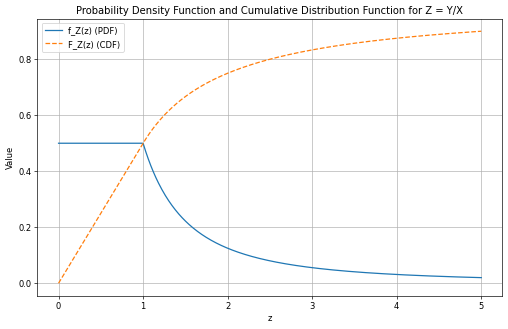

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the PDF f_Z(z)
def f_Z(z):
    if z < 0:
        return 0
    elif 0 <= z <= 1:
        return 0.5
    elif z > 1:
        return 1 / (2 * z**2)
    return 0

# Define the CDF F_Z(z)
def F_Z(z):
    if z < 0:
        return 0
    elif 0 <= z <= 1:
        return 0.5 * z
    elif z > 1:
        return 1 - 1 / (2 * z)
    return 0

# Generate z values for plotting
# We need to cover the ranges defined in the function
z_values = np.linspace(0, 5, 500) # Plot from 0 to 5 to show all cases

# Calculate the corresponding PDF values
pdf_Z_values = [f_Z(val) for val in z_values]

# Calculate the corresponding CDF values
cdf_Z_values = [F_Z(val) for val in z_values]

# Plotting
plt.figure(figsize=(10, 6), dpi=60)
sns.lineplot(x=z_values, y=pdf_Z_values, label='f_Z(z) (PDF)')
sns.lineplot(x=z_values, y=cdf_Z_values, label='F_Z(z) (CDF)', linestyle='--')

plt.title('Probability Density Function and Cumulative Distribution Function for Z = Y/X')
plt.xlabel('z')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

Let $X$ and $Y$ be independent positive random variables (r.v.'s). Let $Z = X/Y$. In what follows, all occurrences of $x, y, z$ are assumed to be positive numbers.

1.  Suppose that $X$ and $Y$ are discrete, with known probability mass functions (PMFs) $p_X$ and $p_Y$. The conditional PMF is given by:
- $p_{Z|Y}(z|y) = p_X(z \cdot y)$

2.  Suppose that $X$ and $Y$ are continuous with known probability density functions (PDFs), $f_X$ and $f_Y$. Find $A$ and $B$ in:
- $f_{Z|Y}(z|y) = A f_X(B) = y \cdot f_X(z \cdot y)$

3.  The integral form for the PDF $f_Z(z)$ is given by:
- $\int_0^\infty (y \cdot f_Y(y) \cdot f_X(y \cdot z)) \mathrm{d}y$

#### $Z = X/Y$ where $X, Y$ are independent Exponential Random Variables

When $X$ and $Y$ are independent exponentially distributed random variables, the distribution of their ratio $Z = X/Y$ can also be analytically derived. However, for consistency and to demonstrate the simulation approach, we will use Monte Carlo simulation to visualize its empirical Probability Density Function (PDF) and Cumulative Distribution Function (CDF).

For $X \sim \text{Exp}(\lambda_X)$ and $Y \sim \text{Exp}(\lambda_Y)$, the PDF of $Z = X/Y$ is given by:

$$ f_Z(z) = \frac{\lambda_X \lambda_Y}{(\lambda_X + \lambda_Y z)^2}, \quad \text{for } z > 0 $$

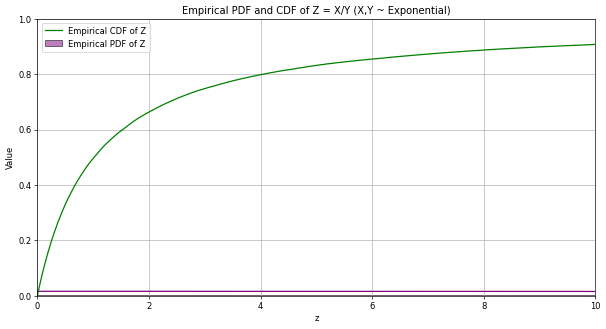

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define parameters for X and Y exponential distributions
lambda_x = 1  # Rate parameter for X (e.g., mean = 1/lambda_x = 1)
lambda_y = 1  # Rate parameter for Y (e.g., mean = 1/lambda_y = 1)

# Number of samples for simulation
num_samples = 100000

# Generate samples for X and Y
X_samples_exp = np.random.exponential(1/lambda_x, num_samples) # numpy uses scale parameter (1/lambda)
Y_samples_exp = np.random.exponential(1/lambda_y, num_samples)

# Calculate Z = X/Y
Z_samples_exp = X_samples_exp / Y_samples_exp

# Plotting the empirical PDF and CDF on a single figure
plt.figure(figsize=(12, 6), dpi=60)

sns.histplot(Z_samples_exp, bins=100, stat='density', kde=True, color='purple', label='Empirical PDF of Z')
sns.ecdfplot(Z_samples_exp, color='green', label='Empirical CDF of Z')

plt.title('Empirical PDF and CDF of Z = X/Y (X,Y ~ Exponential)')
plt.xlabel('z')
plt.ylabel('Value')
plt.xlim(0, 10) # Exponential ratio distributions are usually concentrated near 0 with a long tail
plt.grid(True)
plt.legend()
plt.show()

#### Scenario: $Z = X/Y$ where $X, Y$ are independent Normal Random Variables

When $X$ and $Y$ are independent normally distributed random variables, the distribution of their ratio $Z = X/Y$ is more complex than the uniform case. It generally follows a Cauchy-like distribution, especially if $Y$ can take values close to zero. A common way to explore this distribution is through Monte Carlo simulation.

Here, we will simulate values for $X$ and $Y$ from normal distributions and then compute the ratio $Z = X/Y$. We will then visualize the empirical Probability Density Function (PDF) using a histogram and the empirical Cumulative Distribution Function (CDF).

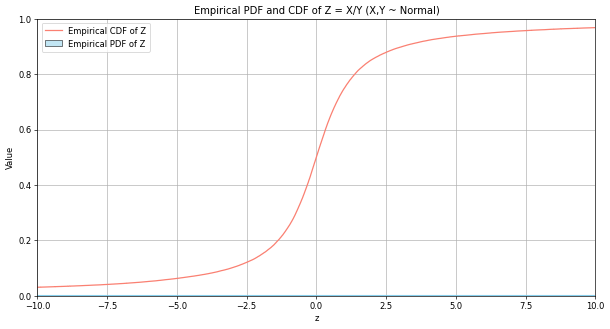

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define parameters for X and Y normal distributions
mu_x = 0  # Mean of X
sigma_x = 1 # Standard deviation of X

mu_y = 0  # Mean of Y
sigma_y = 1 # Standard deviation of Y

# Number of samples for simulation
num_samples = 100000

# Generate samples for X and Y
X_samples = np.random.normal(mu_x, sigma_x, num_samples)
Y_samples = np.random.normal(mu_y, sigma_y, num_samples)

# Calculate Z = X/Y. Handle division by zero by filtering out Y values close to zero.
# A small epsilon is used to prevent extremely large Z values that can distort the plot.
epsilon = 1e-6
Y_samples_filtered = Y_samples[np.abs(Y_samples) > epsilon]
X_samples_filtered = X_samples[np.abs(Y_samples) > epsilon]

Z_samples = X_samples_filtered / Y_samples_filtered

# Plotting the empirical PDF and CDF on a single figure
plt.figure(figsize=(12, 6), dpi=60)

sns.histplot(Z_samples, bins=100, stat='density', kde=True, color='skyblue', label='Empirical PDF of Z')
sns.ecdfplot(Z_samples, color='salmon', label='Empirical CDF of Z')

plt.title('Empirical PDF and CDF of Z = X/Y (X,Y ~ Normal)')
plt.xlabel('z')
plt.ylabel('Value')
plt.xlim(-10, 10) # Limit x-axis for better visualization due to heavy tails
plt.grid(True)
plt.legend()
plt.show()

#### Stick Breaking Problem

We aim to calculate quantities that are difficult using conditional expectation and variance.

**Key Concepts:**
1.  Law of Iterated Expectations: $E[X] = E[E[X|Y]]$
2.  Law of Total Variance: $Var(X) = E[Var(X|Y)] + Var(E[X|Y])$
3.  Uniform Distribution Properties: For $Y \sim U[a,b]$, $E[Y] = \frac{a+b}{2}$ and $Var(Y) = \frac{(b-a)^2}{12}$

**Problem Description:**
We start with a stick of fixed length $l$. We break it uniformly at random along its length and keep the left portion. Let's call the length of this left portion $Y$.

We then repeat the process: we pick another point uniformly at random on the remaining stick (of length $Y$) and keep its left side. Let's call this final length $X$.

Goal:Calculate $E[X]$ and $Var(X)$.

Calculations:

Step 1: Characterize Y
$Y \sim U[0,l]$
$E[Y] = \frac{l}{2}$
$Var(Y) = \frac{l^2}{12}$

Step 2: Characterize X given Y
Given $Y=y$, $X$ is a uniform random variable on the interval $[0, y]$.
So, $X|Y \sim U[0,Y]$
$E[X|Y] = \frac{Y}{2}$
$Var(X|Y) = \frac{Y^2}{12}$

Step 3: Calculate $E[X]$ using the Law of Iterated Expectations
$E[X] = E[E[X|Y]] = E\left[\frac{Y}{2}\right] = \frac{1}{2} E[Y] = \frac{1}{2} \left(\frac{l}{2}\right) = \frac{l}{4}$

Step 4: Calculate $Var(X)$ using the Law of Total Variance
$Var(X) = E[Var(X|Y)] + Var(E[X|Y])$

First, calculate $E[Var(X|Y)]$:
$E[Var(X|Y)] = E\left[\frac{Y^2}{12}\right] = \frac{1}{12} E[Y^2]$

To find $E[Y^2]$, we use the formula $Var(Y) = E[Y^2] - (E[Y])^2$, so $E[Y^2] = Var(Y) + (E[Y])^2$.
$E[Y^2] = \frac{l^2}{12} + \left(\frac{l}{2}\right)^2 = \frac{l^2}{12} + \frac{l^2}{4} = \frac{l^2 + 3l^2}{12} = \frac{4l^2}{12} = \frac{l^2}{3}$

Therefore,
$E[Var(X|Y)] = \frac{1}{12} \left(\frac{l^2}{3}\right) = \frac{l^2}{36}$

Next, calculate $Var(E[X|Y])$:
$Var(E[X|Y]) = Var\left(\frac{Y}{2}\right) = \left(\frac{1}{2}\right)^2 Var(Y) = \frac{1}{4} Var(Y) = \frac{1}{4} \left(\frac{l^2}{12}\right) = \frac{l^2}{48}$

Finally, sum these two components to get $Var(X)$:
$Var(X) = E[Var(X|Y)] + Var(E[X|Y]) = \frac{l^2}{36} + \frac{l^2}{48}$
To add these fractions, find a common denominator (144):
$Var(X) = \frac{4l^2}{144} + \frac{3l^2}{144} = \frac{7l^2}{144}$